# Phase 5 — Évaluation hors échantillon, protocole final

**Question de soutenance :** comment prouver que la sélection ne voit pas le futur,
puis éviter de confondre le meilleur résultat observé parmi 240 essais avec une
surperformance établie ?

> **Actualisation sûre — release MAD/BAM (2026-08-09).** Ce notebook est exécuté sur
> les artefacts finaux versionnés. `full_2021` est exprimé en **MAD**, avec conversion
> causale des niveaux de prix ETF au taux de référence officiel Bank Al-Maghrib, sans
> couverture de change. `etf_2017` est un univers composé uniquement d'ETF en **USD**,
> commence en novembre 2004 et n'est pas modifié par cette correction. Les niveaux de
> Sharpe des deux univers ne sont donc pas comparés entre eux. Les écarts ponctuels sont
> descriptifs; le livrable est un prototype de recherche, ni un conseil, ni un système
> déployé.

In [1]:
from pathlib import Path
import json

SAFE_ROOT = Path.cwd()
if not (SAFE_ROOT / "data" / "gold").exists():
    SAFE_ROOT = SAFE_ROOT.parent
GOLD_RELEASE = SAFE_ROOT / "data" / "gold"

snapshot = json.loads((GOLD_RELEASE / "snapshot_manifest.json").read_text())
currency = json.loads((GOLD_RELEASE / "currency_manifest.json").read_text())
assert snapshot["git_dirty"] is False, "The published snapshot itself must have clean provenance."
assert currency["universes"]["full_2021"]["base_currency"] == "MAD"
assert currency["universes"]["etf_2017"]["base_currency"] == "USD"
print("Published snapshot:", snapshot["git_commit"][:12])
print("full_2021: MAD, official BAM FX, unhedged")
print("etf_2017: USD-only, FX correction not applicable")

Published snapshot: ae87f48207d1
full_2021: MAD, official BAM FX, unhedged
etf_2017: USD-only, FX correction not applicable


In [2]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd()
if not (ROOT / "data" / "gold").exists():
    ROOT = ROOT.parent
GOLD = ROOT / "data" / "gold"
BRONZE = ROOT / "data" / "bronze"

def load_json(name):
    return json.loads((GOLD / name).read_text(encoding="utf-8"))

snapshot = load_json("snapshot_manifest.json")
assert snapshot["git_dirty"] is False, "Le snapshot source doit être propre."

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

COLORS = {
    "equal_weight": "#94a3b8",
    "min_variance_lw": "#14b8a6",
    "max_sharpe": "#2563eb",
    "regime_conditional": "#f59e0b",
    "dcc_garch": "#0f766e",
    "rf_signal": "#8b5cf6",
    "xgb_signal": "#ef4444",
    "rf_signal_tuned": "#8b5cf6",
    "xgb_signal_tuned": "#ef4444",
}

display(Markdown(
    f"**Snapshot canonique :** `{snapshot['git_commit'][:12]}`  "
    f"— généré le `{snapshot['generated_at_utc']}` — arbre source propre."
))

**Snapshot canonique :** `ae87f48207d1`  — généré le `2026-08-09T02:32:55.411586+00:00` — arbre source propre.

In [3]:
protocol = load_json("phase5_validation_protocol.json")
paired = load_json("paired_comparison_results.json")
reality = load_json("reality_check_results.json")
nested = load_json("nested_walkforward_results.json")
phase5 = load_json("phase5_results.json")
rc_series = pd.read_parquet(GOLD / "reality_check_series.parquet")
rc_series["Date"] = pd.to_datetime(rc_series["Date"])

assert protocol["protocol"] == "purged_walk_forward"
assert paired["multiple_testing"]["status"] == "established"

## Sélection forward-only : train, purge/embargo, validation

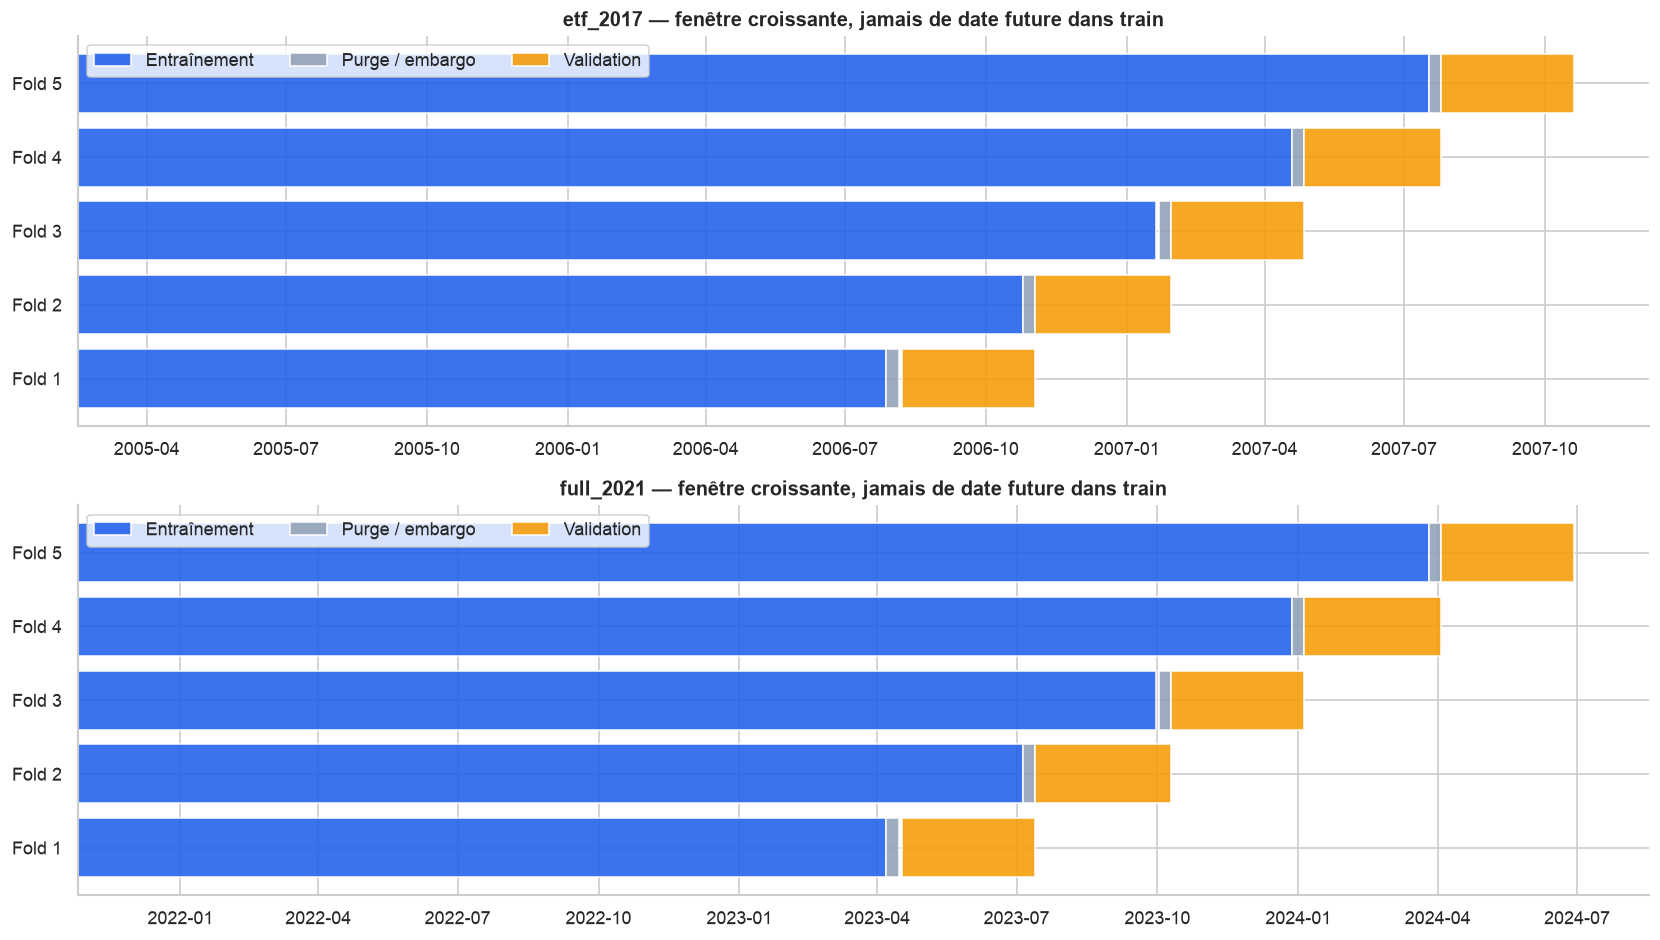

In [4]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
for ax, universe in zip(axes, sorted(protocol["universes"])):
    rf_folds = protocol["universes"][universe]["random_forest"]["folds"]
    xgb_folds = protocol["universes"][universe]["xgboost"]["folds"]
    assert rf_folds == xgb_folds, "Les deux sélecteurs doivent partager les mêmes frontières."
    for y, fold in enumerate(rf_folds, start=1):
        segments = [
            ("Entraînement", fold["train_start"], fold["train_end"], "#2563eb"),
            ("Purge / embargo", fold["embargo_start"], fold["embargo_end"], "#94a3b8"),
            ("Validation", fold["val_start"], fold["val_end"], "#f59e0b"),
        ]
        for label, start, end, color in segments:
            start = pd.Timestamp(start)
            end = pd.Timestamp(end)
            ax.barh(y, (end - start).days + 1, left=mdates.date2num(start), color=color, alpha=0.9, label=label if y == 1 else None)
        assert pd.Timestamp(fold["train_end"]) < pd.Timestamp(fold["val_start"])
    ax.set_yticks(range(1, len(rf_folds) + 1), [f"Fold {i}" for i in range(1, len(rf_folds) + 1)])
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.set_title(f"{universe} — fenêtre croissante, jamais de date future dans train")
    ax.legend(loc="upper left", ncol=3)
plt.tight_layout()
plt.show()

## Test pairé : distribution de la différence, pas juxtaposition d'intervalles marginaux

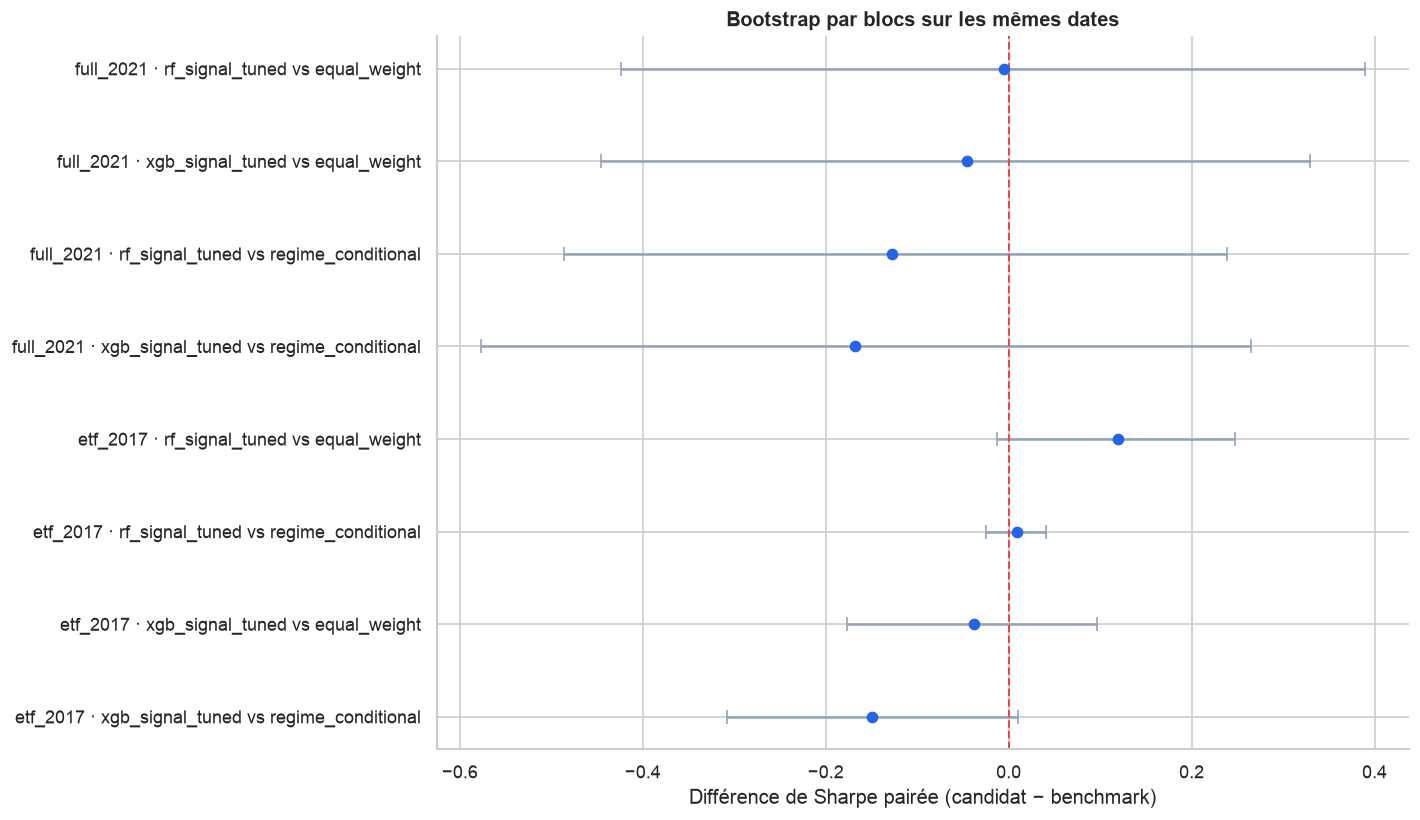

,universe,candidate,benchmark,sharpe_diff,sharpe_diff_ci,p_value_no_outperformance,prob_sharpe_diff_positive
2,etf_2017,xgb_signal_tuned,regime_conditional,-0.149,"[-0.308359, 0.010087]",0.939,0.059
3,etf_2017,xgb_signal_tuned,equal_weight,-0.038,"[-0.176841, 0.09607]",0.671,0.316
0,etf_2017,rf_signal_tuned,regime_conditional,+0.009,"[-0.025097, 0.040947]",0.326,0.658
1,etf_2017,rf_signal_tuned,equal_weight,+0.120,"[-0.013074, 0.24747]",0.066,0.932
6,full_2021,xgb_signal_tuned,regime_conditional,-0.168,"[-0.576904, 0.264368]",0.740,0.274
4,full_2021,rf_signal_tuned,regime_conditional,-0.128,"[-0.486369, 0.239164]",0.715,0.293
7,full_2021,xgb_signal_tuned,equal_weight,-0.046,"[-0.445312, 0.328987]",0.587,0.427
5,full_2021,rf_signal_tuned,equal_weight,-0.005,"[-0.424088, 0.389113]",0.513,0.483


In [5]:
comparisons = pd.DataFrame(paired["comparisons"])
comparisons["label"] = comparisons["universe"] + " · " + comparisons["candidate"] + " vs " + comparisons["benchmark"]
comparisons = comparisons.sort_values(["universe", "sharpe_diff"])

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(comparisons))
low = comparisons["sharpe_diff"] - comparisons["sharpe_diff_ci"].str[0]
high = comparisons["sharpe_diff_ci"].str[1] - comparisons["sharpe_diff"]
ax.errorbar(comparisons["sharpe_diff"], y, xerr=np.vstack([low, high]), fmt="o", color="#2563eb", ecolor="#94a3b8", capsize=4)
ax.axvline(0, color="#ef4444", lw=1.2, ls="--")
ax.set_yticks(y, comparisons["label"])
ax.set_xlabel("Différence de Sharpe pairée (candidat − benchmark)")
ax.set_title("Bootstrap par blocs sur les mêmes dates")
plt.tight_layout()
plt.show()

display(comparisons[["universe", "candidate", "benchmark", "sharpe_diff", "sharpe_diff_ci", "p_value_no_outperformance", "prob_sharpe_diff_positive"]].style.format({
    "sharpe_diff": "{:+.3f}",
    "p_value_no_outperformance": "{:.3f}",
    "prob_sharpe_diff_positive": "{:.3f}",
}))

## White Reality Check et Hansen SPA — benchmark primaire fixé avant les résultats

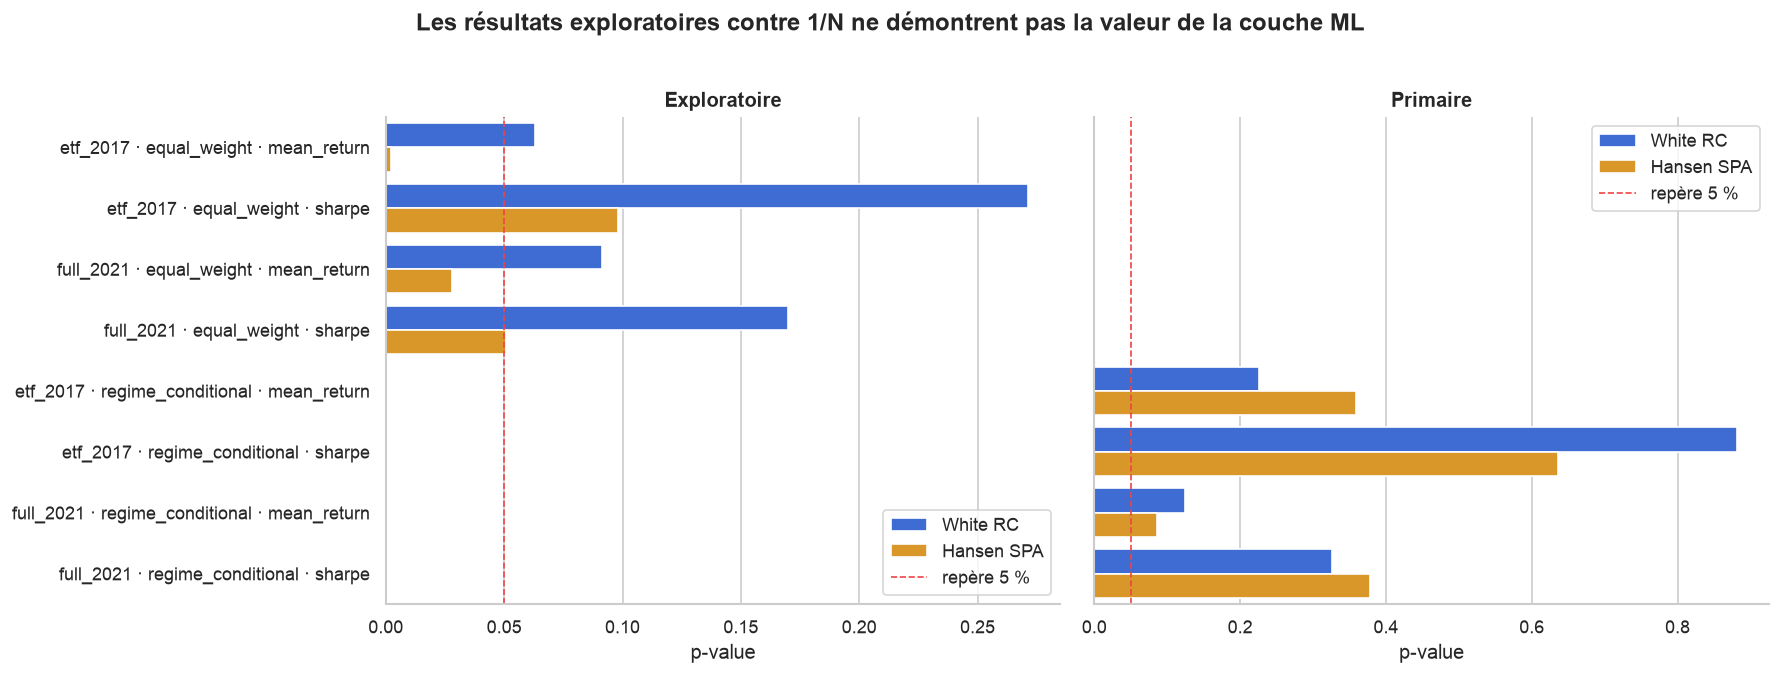

,univers,benchmark,statistique,statut,N,candidats SPA retenus
0,etf_2017,equal_weight,mean_return,exploratory,240,239
2,etf_2017,equal_weight,sharpe,exploratory,240,240
4,etf_2017,regime_conditional,mean_return,primary,240,237
6,etf_2017,regime_conditional,sharpe,primary,240,239
8,full_2021,equal_weight,mean_return,exploratory,240,240
10,full_2021,equal_weight,sharpe,exploratory,240,240
12,full_2021,regime_conditional,mean_return,primary,240,240
14,full_2021,regime_conditional,sharpe,primary,240,238


In [6]:
test_rows = []
for universe, payload in reality["universes"].items():
    for name, result in payload["tests"].items():
        benchmark, statistic = name.split("__")
        test_rows.extend([
            {"univers": universe, "benchmark": benchmark, "statistique": statistic, "test": "White RC", "p-value": result["reality_check_p_value"], "statut": result["status"], "candidats SPA retenus": result["spa_candidates_retained"], "N": result["n_candidates"]},
            {"univers": universe, "benchmark": benchmark, "statistique": statistic, "test": "Hansen SPA", "p-value": result["spa_p_value"], "statut": result["status"], "candidats SPA retenus": result["spa_candidates_retained"], "N": result["n_candidates"]},
        ])
tests = pd.DataFrame(test_rows)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, (status, frame) in zip(axes, tests.groupby("statut", sort=False)):
    labels = frame["univers"] + " · " + frame["benchmark"] + " · " + frame["statistique"]
    sns.barplot(data=frame.assign(label=labels), y="label", x="p-value", hue="test", ax=ax, palette=["#2563eb", "#f59e0b"])
    ax.axvline(0.05, color="#ef4444", ls="--", lw=1, label="repère 5 %")
    ax.set_title("Primaire" if status == "primary" else "Exploratoire")
    ax.set_ylabel("")
    ax.legend(title="")
plt.suptitle("Les résultats exploratoires contre 1/N ne démontrent pas la valeur de la couche ML", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

display(tests.drop_duplicates(["univers", "benchmark", "statistique"])[["univers", "benchmark", "statistique", "statut", "N", "candidats SPA retenus"]])

## Inflation de sélection : 240 configurations observées sur le test

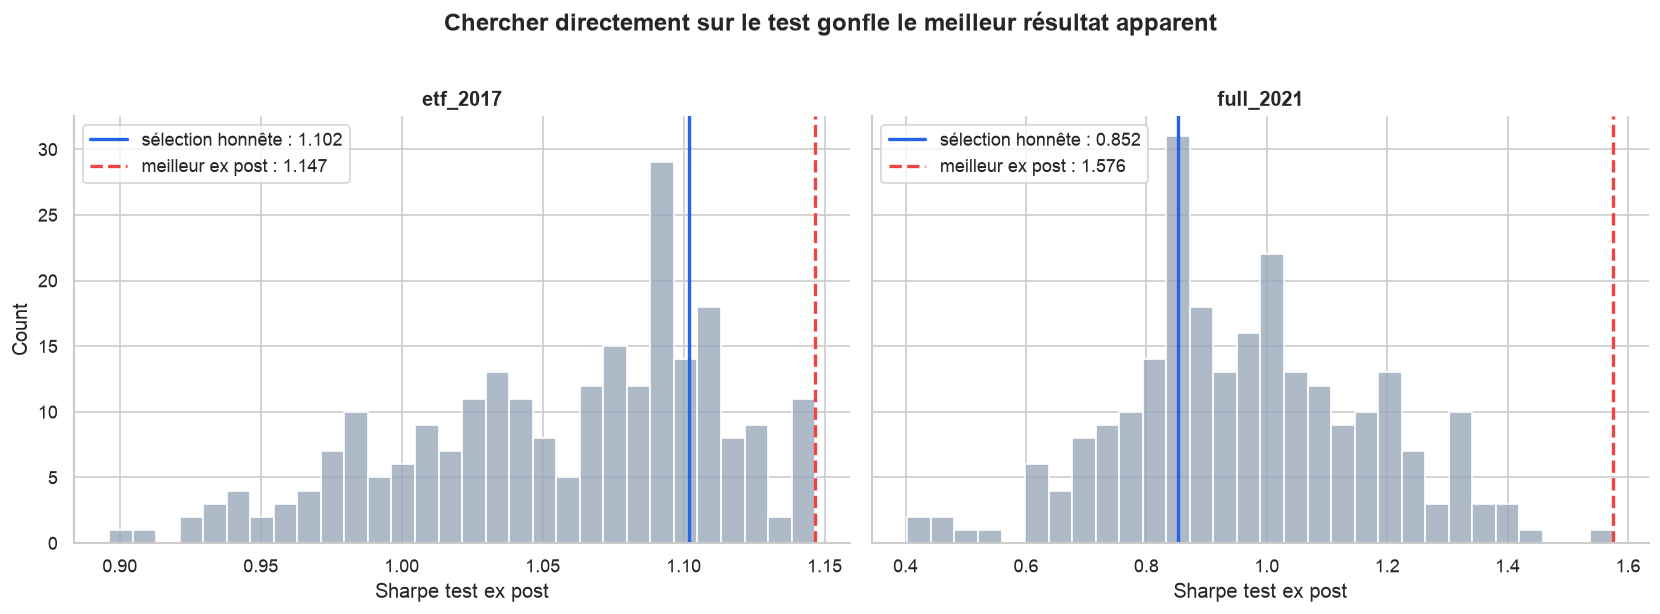

In [7]:
def sharpe_from_log_returns(values):
    values = pd.Series(values).dropna()
    return np.sqrt(252) * values.mean() / values.std(ddof=1)

candidate_sharpes = (
    rc_series.groupby(["universe", "candidate"], sort=False)["net_return"]
    .apply(sharpe_from_log_returns)
    .rename("Sharpe test ex post")
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, (universe, frame) in zip(axes, candidate_sharpes.groupby("universe", sort=True)):
    sns.histplot(frame["Sharpe test ex post"], bins=30, color="#94a3b8", ax=ax)
    selected = max(
        item["test_sharpe_net"]
        for item in phase5[universe]["tuned"].values()
    )
    ex_post_best = frame["Sharpe test ex post"].max()
    ax.axvline(selected, color="#2563eb", lw=2, label=f"sélection honnête : {selected:.3f}")
    ax.axvline(ex_post_best, color="#ef4444", lw=2, ls="--", label=f"meilleur ex post : {ex_post_best:.3f}")
    ax.set_title(universe)
    ax.legend()
plt.suptitle("Chercher directement sur le test gonfle le meilleur résultat apparent", y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

## Walk-forward imbriqué : davantage d'OOS, mais un classement dépendant du protocole et de sa fenêtre

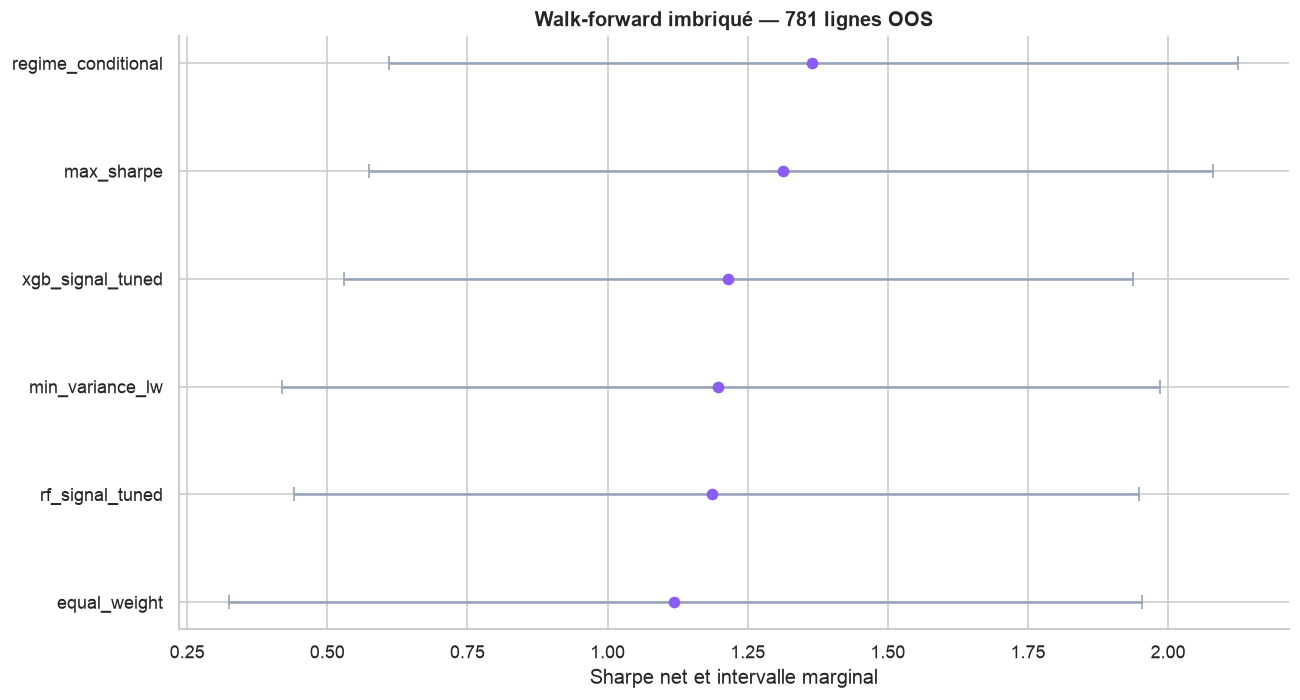


**DSR = 0.6707 sur 198 configurations.**  
La valeur est reportée sans adjectif : aucun seuil d'interprétation n'a été pré-spécifié.
Le classement observé dépend du protocole **et de la fenêtre OOS associée** ; le chevauchement
des intervalles marginaux n'établit ni supériorité ni équivalence.


In [8]:
nested_rows = []
for strategy, result in nested["strategies"].items():
    nested_rows.append({
        "stratégie": strategy,
        "Sharpe net": result["sharpe_net"],
        "borne basse": result["ci"][0],
        "borne haute": result["ci"][1],
        "largeur IC": result["ci_width"],
    })
nested_df = pd.DataFrame(nested_rows).sort_values("Sharpe net")

fig, ax = plt.subplots(figsize=(11, 6))
y = np.arange(len(nested_df))
ax.errorbar(
    nested_df["Sharpe net"], y,
    xerr=np.vstack([nested_df["Sharpe net"] - nested_df["borne basse"], nested_df["borne haute"] - nested_df["Sharpe net"]]),
    fmt="o", capsize=4, color="#8b5cf6", ecolor="#94a3b8",
)
ax.set_yticks(y, nested_df["stratégie"])
ax.set_xlabel("Sharpe net et intervalle marginal")
ax.set_title(f"Walk-forward imbriqué — {nested['design']['n_oos_rows']} lignes OOS")
plt.tight_layout()
plt.show()

display(Markdown(f"""
**DSR = {nested['best_dsr_vs_search']:.4f} sur {nested['n_search_trials']} configurations.**  
La valeur est reportée sans adjectif : aucun seuil d'interprétation n'a été pré-spécifié.
Le classement observé dépend du protocole **et de la fenêtre OOS associée** ; le chevauchement
des intervalles marginaux n'établit ni supériorité ni équivalence.
"""))

### Ce que ce notebook établit

- La sélection est strictement antérieure à chaque validation.
- Les différences sont évaluées de façon pairée sur les mêmes dates.
- La correction White/SPA couvre les 240 configurations accessibles.
- Aucun candidat n'établit de surperformance contre le comparateur primaire pré-spécifié.

### Ce qu'il n'établit pas

- L'absence de rejet n'est pas une preuve d'équivalence.
- Les comparaisons contre l'équipondéré restent exploratoires.
- Huit comparaisons externes ont été lues ; cette multiplicité externe reste signalée.